<a href="https://colab.research.google.com/github/Praveen2005-08/job_placement_project/blob/main/job_prediction%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ORIGINAL DATASET
Degree Branch  CGPA  Aptitude_Score  Communication_Score  Projects Internship  Internship_Months  Backlogs  Attendance_Percent            Skill  Skill_Count Placement_Status
   MCA   MECH  7.26            53.0                 85.0         3         No                  0       0.0               80.80            Cloud            0           Placed
  B.Sc     IT  8.40            78.0                 31.0         1         No                  0       0.0               90.00              C++            1           Placed
  B.Sc    ECE  7.55            59.0                 61.0         0        Yes                  8       0.0               68.20              C++            1           Placed
  B.Sc    CSE  4.50            86.0                 62.0         1        Yes                  6       0.0               80.45            Cloud            3           Placed
   B.E    EEE  7.36            91.0                 33.0         0         No                  0       0.0       

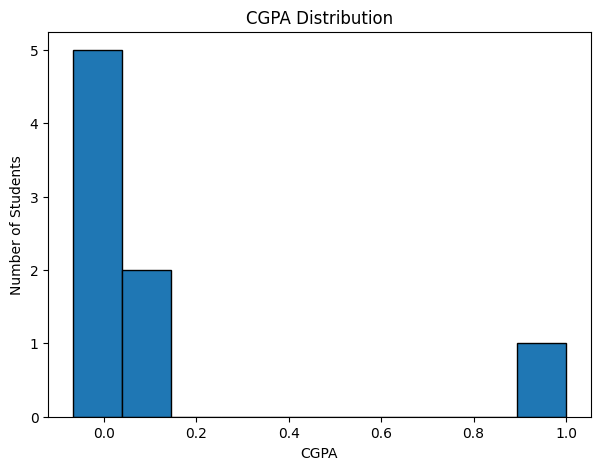

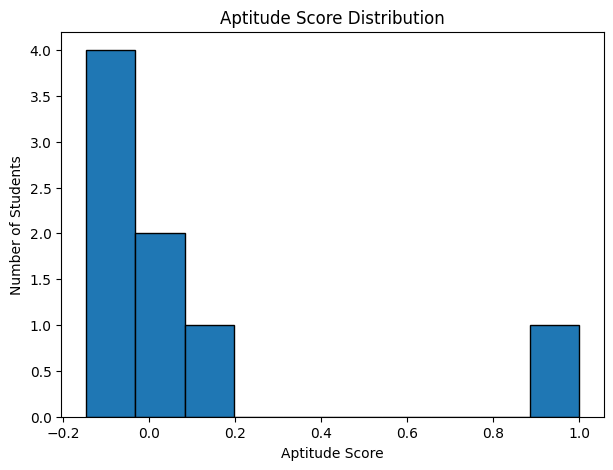

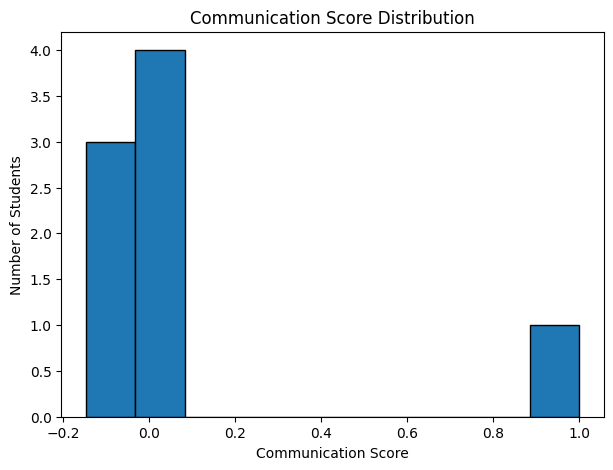

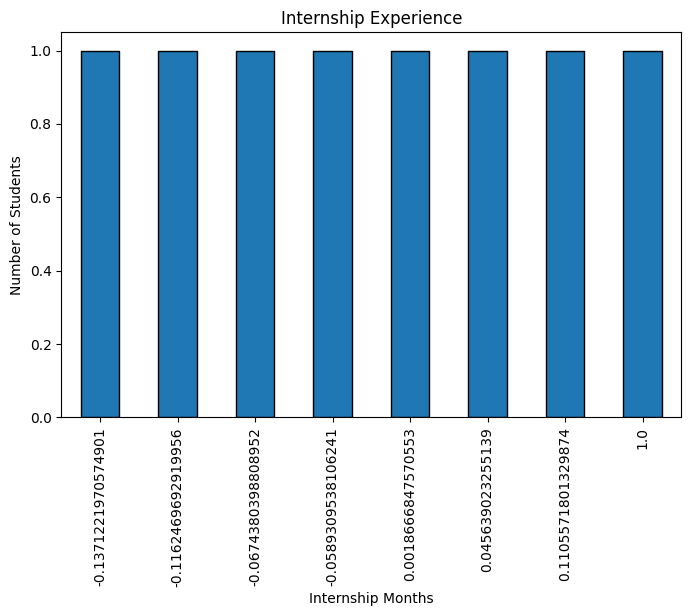

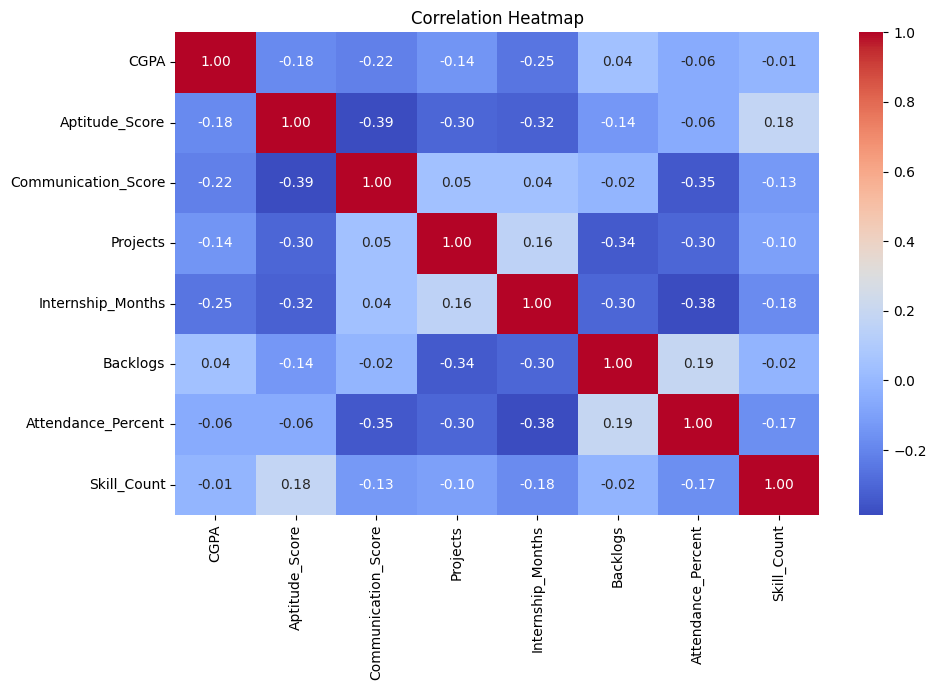

JOB PLACEMENT PREDICTION

Dataset Shape:
(8, 8)

Columns:
['CGPA', 'Aptitude_Score', 'Communication_Score', 'Projects', 'Internship_Months', 'Backlogs', 'Attendance_Percent', 'Skill_Count']

Placement Status:
Placement_Status
Placed        4
Not Placed    4
Name: count, dtype: int64

Selected Features:
['CGPA', 'Aptitude_Score', 'Communication_Score', 'Projects', 'Internship_Months', 'Backlogs', 'Attendance_Percent', 'Skill_Count']

Target:
Placement_Status

Training Data: (6, 8)
Testing Data : (2, 8)

Model training completed!

MODEL RESULTS

Accuracy:
0.0 %

RMSE:
1.0

R² Score:
-3.0

Confusion Matrix:
[[0 1]
 [1 0]]

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.00      0.00      0.00       1.0
      Placed       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0


FEATURE IMPORTANCE
  

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix
)




df = pd.read_csv("job_prediction.csv")

print("=" * 70)
print("ORIGINAL DATASET")
print("=" * 70)



# 1. DISPLAY ALL ORIGINAL DATA

print(df.to_string(index=False))


# 2. CHECK MISSING VALUES

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())


# 3. CHECK DUPLICATES

print("\n" + "=" * 70)
print("DUPLICATE DATA")
print("=" * 70)

print("Duplicate Rows:", df.duplicated().sum())



# 4. DATA TYPES

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(df.dtypes)



# 5. CATEGORICAL AND NUMERICAL COLUMNS


categorical_columns = [
    "Gender",
    "City",
    "Degree",
    "Branch",
    "Internship",
    "Skill",
    "Placement_Status"
]

numerical_columns = [
    "Age",
    "CGPA",
    "Aptitude_Score",
    "Communication_Score",
    "Projects",
    "Internship_Months",
    "Backlogs",
    "Attendance_Percent",
    "Skill_Count",
    "Salary_LPA"
]

print("\n" + "=" * 70)
print("CATEGORICAL COLUMNS")
print("=" * 70)

print(categorical_columns)

print("\n" + "=" * 70)
print("NUMERICAL COLUMNS")
print("=" * 70)

print(numerical_columns)



# CLEANING STARTS


print("\n" + "=" * 70)
print("CLEANING DATA")
print("=" * 70)



# 6. REMOVE DUPLICATE ROWS

before = len(df)

df = df.drop_duplicates()

after = len(df)

print("\nDuplicate rows removed:", before - after)



# 7. REMOVE EXTRA SPACES


for column in categorical_columns:
    if column in df.columns:
        df[column] = (
            df[column]
            .astype("string")
            .str.strip()
        )






# 9. CLEAN INTERNSHIP


df["Internship"] = df["Internship"].replace({
    "yes": "Yes",
    "YES": "Yes",
    "Y": "Yes",

    "no": "No",
    "NO": "No",
    "N": "No"
})



# 10. CLEAN PLACEMENT STATUS


df["Placement_Status"] = df["Placement_Status"].replace({
    "placed": "Placed",
    "PLACED": "Placed",
    "Yes": "Placed",

    "not placed": "Not Placed",
    "NOT PLACED": "Not Placed",
    "No": "Not Placed"
})



# 11. CLEAN DEGREE


df["Degree"] = df["Degree"].replace({
    "BTECH": "B.Tech",
    "B Tech": "B.Tech",

    "BE": "B.E",
    "B.E.": "B.E",
    "B E": "B.E",

    "BSC": "B.Sc",
    "B.Sc.": "B.Sc",

    "bca": "BCA",

    "mca": "MCA",

    "MTECH": "M.Tech",

    "mba": "MBA",

    "BCOM": "B.Com",
    "B.Com.": "B.Com"
})



# 12. CLEAN BRANCH


df["Branch"] = df["Branch"].replace({
    "cse": "CSE",
    "Computer Science": "CSE",

    "it": "IT",
    "Information Technology": "IT",

    "ece": "ECE",
    "eee": "EEE",
    "mech": "MECH",
    "civil": "CIVIL",
    "aiml": "AIML"
})



# 13. CLEAN CGPA


df["CGPA"] = (
    df["CGPA"]
    .astype("string")
    .str.extract(r"(\d+\.?\d*)")[0]
)

df["CGPA"] = pd.to_numeric(
    df["CGPA"],
    errors="coerce"
)



# 14. CLEAN ATTENDANCE


df["Attendance_Percent"] = (
    df["Attendance_Percent"]
    .astype("string")
    .str.extract(r"(\d+\.?\d*)")[0]
)

df["Attendance_Percent"] = pd.to_numeric(
    df["Attendance_Percent"],
    errors="coerce"
)



# 15. CONVERT NUMERICAL COLUMNS


for column in numerical_columns:

    if column in df.columns:

        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )



# 16. HANDLE INVALID CGPA


df.loc[
    (df["CGPA"] < 0) |
    (df["CGPA"] > 10),
    "CGPA"
] = None



# 17. HANDLE INVALID APTITUDE SCORE


df.loc[
    (df["Aptitude_Score"] < 0) |
    (df["Aptitude_Score"] > 100),
    "Aptitude_Score"
] = None



# 18. HANDLE INVALID COMMUNICATION SCORE


df.loc[
    (df["Communication_Score"] < 0) |
    (df["Communication_Score"] > 100),
    "Communication_Score"
] = None



# 19. HANDLE INVALID ATTENDANCE


df.loc[
    (df["Attendance_Percent"] < 0) |
    (df["Attendance_Percent"] > 100),
    "Attendance_Percent"
] = None



# 20. HANDLE MISSING NUMERICAL VALUES


for column in numerical_columns:

    if column in df.columns:

        median_value = df[column].median()

        df[column] = df[column].fillna(
            median_value
        )



# 21. HANDLE MISSING CATEGORICAL VALUES

for column in categorical_columns:

    if column in df.columns:

        mode_value = df[column].mode()

        if len(mode_value) > 0:

            df[column] = df[column].fillna(
                mode_value[0]
            )








# 23. FINAL CHECK


print("\n" + "=" * 70)
print("FINAL CLEAN DATA")
print("=" * 70)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nFinal Data Types:")
print(df.dtypes)



# 24. DISPLAY ALL CLEANED DATA


print("\n" + "=" * 70)
print("ALL 150 CLEANED RECORDS")
print("=" * 70)

print(df.to_string(index=False))



# 25. SAVE CLEAN DATASET


df.to_csv(
    "job_prediction.csv",
    index=False
)









# Load cleaned dataset
df = pd.read_csv("job_prediction.csv")

# Select numerical columns
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("-" * 70)
print("NUMERICAL COLUMNS")

print(numerical_columns.tolist())



# 1. MEAN


print("\n" + "-" * 70)
print("MEAN")


print(df[numerical_columns].mean())



# 2. MEDIAN


print("\n" + "-" * 70)
print("MEDIAN")


print(df[numerical_columns].median())



# 3. MINIMUM


print("\n" + "-" * 70)
print("MINIMUM")


print(df[numerical_columns].min())



# 4. MAXIMUM


print("\n" + "-" * 70)
print("MAXIMUM")


print(df[numerical_columns].max())



# 5. RANGE
# Range = Maximum - Minimum


print("\n" + "-" * 70)
print("RANGE")


range_values = (
    df[numerical_columns].max()
    - df[numerical_columns].min()
)

print(range_values)



# 6. VARIANCE


print("\n" + "-" * 70)
print("VARIANCE")

print(df[numerical_columns].var())



# 7. STANDARD DEVIATION


print("\n" + "-" * 70)
print("STANDARD DEVIATION")


print(df[numerical_columns].std())



# 8. CORRELATION MATRIX


print("\n" + "-" * 70)
print("CORRELATION MATRIX")


correlation = df[numerical_columns].corr()

print(correlation)



# 9. CORRELATION WITH PLACEMENT FEATURES


print("\n" + "-" * 70)
print("CORRELATION WITH OTHER NUMERICAL FEATURES")


if "Salary_LPA" in df.columns:

    print("\nCorrelation with Salary_LPA:")
    print(
        correlation["Salary_LPA"]
        .sort_values(ascending=False)
    )



# 10. COMPLETE STATISTICAL SUMMARY


print("\n" + "-" * 70)
print("COMPLETE STATISTICAL SUMMARY")


statistics = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Minimum": df[numerical_columns].min(),
    "Maximum": df[numerical_columns].max(),
    "Range": (
        df[numerical_columns].max()
        - df[numerical_columns].min()
    ),
    "Variance": df[numerical_columns].var(),
    "Standard_Deviation": df[numerical_columns].std()
})

print(statistics.round(2))


# 11. SAVE STATISTICS TO CSV
# Saving to new CSV files to avoid overwriting the original 'job_prediction.csv'
statistics.to_csv(
    "job_prediction1.csv",
    index=False
)

correlation.to_csv(
    "job_prediction1.csv",
    index=False
)







# LOAD DATA

df = pd.read_csv("job_prediction1.csv")

# Remove unwanted index column
if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())



# CONVERT DATA TO NUMERIC


columns = [
    "CGPA",
    "Aptitude_Score",
    "Communication_Score",
    "Projects",
    "Internship_Months",
    "Backlogs",
    "Attendance_Percent",
    "Skill_Count"
]

for col in columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )



# 1. CGPA HISTOGRAM


plt.figure(figsize=(7,5))

plt.hist(
    df["CGPA"].dropna(),
    bins=10,
    edgecolor="black"
)

plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")

plt.show()



# 2. APTITUDE SCORE HISTOGRAM


plt.figure(figsize=(7,5))

plt.hist(
    df["Aptitude_Score"].dropna(),
    bins=10,
    edgecolor="black"
)

plt.title("Aptitude Score Distribution")
plt.xlabel("Aptitude Score")
plt.ylabel("Number of Students")

plt.show()



# 3. COMMUNICATION SCORE HISTOGRAM


plt.figure(figsize=(7,5))

plt.hist(
    df["Communication_Score"].dropna(),
    bins=10,
    edgecolor="black"
)

plt.title("Communication Score Distribution")
plt.xlabel("Communication Score")
plt.ylabel("Number of Students")

plt.show()



# 4. INTERNSHIP MONTHS BAR CHART


plt.figure(figsize=(8,5))

df["Internship_Months"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Internship Experience")
plt.xlabel("Internship Months")
plt.ylabel("Number of Students")

plt.show()



# 5. CORRELATION HEATMAP


correlation = df.corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()





# 1. LOAD YOUR CURRENT DATA


df = pd.read_csv("job_prediction1.csv")

# Remove unnecessary index column
if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)

print("=" * 70)
print("JOB PLACEMENT PREDICTION")
print("=" * 70)

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())


# 2. CREATE PLACEMENT TARGET



score = (
    0.35 * (df["CGPA"] / 10) +
    0.25 * (df["Aptitude_Score"] / 100) +
    0.15 * (df["Communication_Score"] / 100) +
    0.10 * (df["Projects"] / df["Projects"].max()) +
    0.10 * (df["Internship_Months"] /
            max(df["Internship_Months"].max(), 1)) +
    0.05 * (df["Skill_Count"] /
            max(df["Skill_Count"].max(), 1))
)

# Backlogs reduce placement chance
score = score - (
    0.05 * df["Backlogs"]
)

# Create target
df["Placement_Status"] = np.where(
    score >= score.median(),
    "Placed",
    "Not Placed"
)

print("\nPlacement Status:")
print(df["Placement_Status"].value_counts())


# 3. SELECT FEATURES


features = [
    "CGPA",
    "Aptitude_Score",
    "Communication_Score",
    "Projects",
    "Internship_Months",
    "Backlogs",
    "Attendance_Percent",
    "Skill_Count"
]

target = "Placement_Status"

print("\nSelected Features:")
print(features)

print("\nTarget:")
print(target)



# 4. CREATE X AND Y


X = df[features]

y = df["Placement_Status"].map({
    "Not Placed": 0,
    "Placed": 1
})



# 5. TRAIN-TEST SPLIT


# With only 8 records, use 25% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data :", X_test.shape)



# 6. RANDOM FOREST MODEL


model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("\nModel training completed!")


# 7. PREDICTION


y_pred = model.predict(X_test)



# 8. ACCURACY


accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "=" * 70)
print("MODEL RESULTS")
print("=" * 70)

print("\nAccuracy:")
print(round(accuracy * 100, 2), "%")



# 9. RMSE

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("\nRMSE:")
print(round(rmse, 4))



# 10. R²
r2 = r2_score(
    y_test,
    y_pred
)

print("\nR² Score:")
print(round(r2, 4))


# 11. CONFUSION MATRIX


print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


# 12. CLASSIFICATION REPORT

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Placed",
            "Placed"
        ],
        zero_division=0
    )
)



# 13. FEATURE IMPORTANCE


importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

print(importance)



# 14. PREDICT A NEW STUDENT

new_student = pd.DataFrame({
    "CGPA": [8.2],
    "Aptitude_Score": [82],
    "Communication_Score": [78],
    "Projects": [3],
    "Internship_Months": [6],
    "Backlogs": [0],
    "Attendance_Percent": [88],
    "Skill_Count": [5]
})

prediction = model.predict(
    new_student
)

probability = model.predict_proba(
    new_student
)



# 15. JOB PLACEMENT RESULT


print("\n" + "=" * 70)
print("NEW STUDENT PREDICTION")
print("=" * 70)

if prediction[0] == 1:
    print("\nPrediction: PLACED")
else:
    print("\nPrediction: NOT PLACED")

print("\nProbability of Not Placed:",
      round(probability[0][0] * 100, 2), "%")

print("Probability of Placed:",
      round(probability[0][1] * 100, 2), "%")





